### Class Label Mapping

| Class ID | Folder Name                                       | Number of Images |
| -------- | ------------------------------------------------- | ---------------- |
| 0        | Pepper__bell___Bacterial_spot                     | 997              |
| 1        | Pepper__bell___healthy                            | 1478             |
| 2        | Potato___Early_blight                             | 1000             |
| 3        | Potato___Late_blight                              | 1000             |
| 4        | Potato___healthy                                  | 152              |
| 5        | Tomato_Bacterial_spot                             | 2127             |
| 6        | Tomato_Early_blight                               | 1000             |
| 7        | Tomato_Late_blight                                | 1909             |
| 8        | Tomato_Leaf_Mold                                  | 952              |
| 9        | Tomato_Septoria_leaf_spot                         | 1771             |
| 10       | Tomato_Spider_mites_Two_spotted_spider_mite       | 1676             |
| 11       | Tomato__Target_Spot                               | 1404             |
| 12       | Tomato__Tomato_YellowLeaf__Curl_Virus             | 3208             |
| 13       | Tomato__Tomato_mosaic_virus                       | 373              |
| 14       | Tomato_healthy                                    | 1591             |


In [20]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from sklearn.model_selection import train_test_split
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
import tensorflow as tf
from tensorflow.keras import layers, models



TensorFlow version: 2.18.0
Num GPUs Available:  1


In [3]:
dataset_dir = '../Data/'
class_names = os.listdir(dataset_dir)
class_names.sort()
class_data = []
for class_name in class_names:
    class_path = os.path.join(dataset_dir, class_name)
    if os.path.isdir(class_path):   
        num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        class_data.append([class_name, num_images])
df_class_data = pd.DataFrame(class_data, columns=["Class Name", "Number of Images"])
df_class_data["Class ID"] = df_class_data.index
print(df_class_data)

                                     Class Name  Number of Images  Class ID
0                 Pepper__bell___Bacterial_spot              1500         0
1                        Pepper__bell___healthy              1500         1
2                         Potato___Early_blight              1500         2
3                          Potato___Late_blight              1500         3
4                              Potato___healthy              1500         4
5                         Tomato_Bacterial_spot              2127         5
6                           Tomato_Early_blight              1500         6
7                            Tomato_Late_blight              1909         7
8                              Tomato_Leaf_Mold              1500         8
9                     Tomato_Septoria_leaf_spot              1771         9
10  Tomato_Spider_mites_Two_spotted_spider_mite              1676        10
11                          Tomato__Target_Spot              1500        11
12        To

In [6]:
class_names = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])

X = []
y = []

label_encoder = LabelEncoder()
label_encoder.fit(class_names)

target_size = (128, 128)   

for class_name in class_names:
    class_path = os.path.join(dataset_dir, class_name)
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    label = label_encoder.transform([class_name])[0]

    for image_file in image_files:
        image_path = os.path.join(class_path, image_file)
        image = cv2.imread(image_path)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, target_size)
        X.append(image)
        y.append(label)

X = np.array(X, dtype=np.uint8)
y = np.array(y, dtype=np.int32)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (25782, 128, 128, 3)
y shape: (25782,)


In [16]:
X_gray = np.array([cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in X])
X_gray = X_gray[..., np.newaxis]  # Add channel dimension to keep shape (H, W, 1)
X_temp, X_test, y_temp, y_test = train_test_split(X_gray, y, test_size=0.10, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, stratify=y_temp, random_state=42)

print(f"Training set: {X_train.shape}, Labels: {y_train.shape}")
print(f"Validation set: {X_val.shape}, Labels: {y_val.shape}")
print(f"Test set: {X_test.shape}, Labels: {y_test.shape}")


Training set: (20625, 128, 128, 1), Labels: (20625,)
Validation set: (2578, 128, 128, 1), Labels: (2578,)
Test set: (2579, 128, 128, 1), Labels: (2579,)


In [21]:


num_classes = 15   

model = models.Sequential([
    layers.Input(shape=(128, 128, 1)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


2025-05-02 16:55:08.711210: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-05-02 16:55:08.711841: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-05-02 16:55:08.712142: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1746185108.712544  316425 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1746185108.712950  316425 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,487,311 (32.38 MB)

 Trainable params: 8,486,351 (32.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [22]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)


Epoch 1/20


2025-05-02 16:56:52.774511: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


645/645 ━━━━━━━━━━━━━━━━━━━━ 103s 148ms/step - accuracy: 0.5224 - loss: 1.6647 - val_accuracy: 0.7742 - val_loss: 0.7539
Epoch 2/20
645/645 ━━━━━━━━━━━━━━━━━━━━ 94s 146ms/step - accuracy: 0.7713 - loss: 0.7131 - val_accuracy: 0.6412 - val_loss: 1.2016
Epoch 3/20
645/645 ━━━━━━━━━━━━━━━━━━━━ 92s 142ms/step - accuracy: 0.8349 - loss: 0.5093 - val_accuracy: 0.8514 - val_loss: 0.5081
Epoch 4/20
645/645 ━━━━━━━━━━━━━━━━━━━━ 91s 142ms/step - accuracy: 0.8742 - loss: 0.3885 - val_accuracy: 0.7925 - val_loss: 0.6597
Epoch 5/20
645/645 ━━━━━━━━━━━━━━━━━━━━ 95s 147ms/step - accuracy: 0.9012 - loss: 0.3041 - val_accuracy: 0.8212 - val_loss: 0.5772
Epoch 6/20
645/645 ━━━━━━━━━━━━━━━━━━━━ 93s 145ms/step - accuracy: 0.9167 - loss: 0.2485 - val_accuracy: 0.3553 - val_loss: 4.0485
Epoch 7/20
645/645 ━━━━━━━━━━━━━━━━━━━━ 93s 144ms/step - accuracy: 0.9297 - loss: 0.2152 - val_accuracy: 0.5504 - val_loss: 2.5342
Epoch 8/20
645/645 ━━━━━━━━━━━━━━━━━━━━ 91s 141ms/step - accuracy: 0.9367 - loss: 0.1843 - va

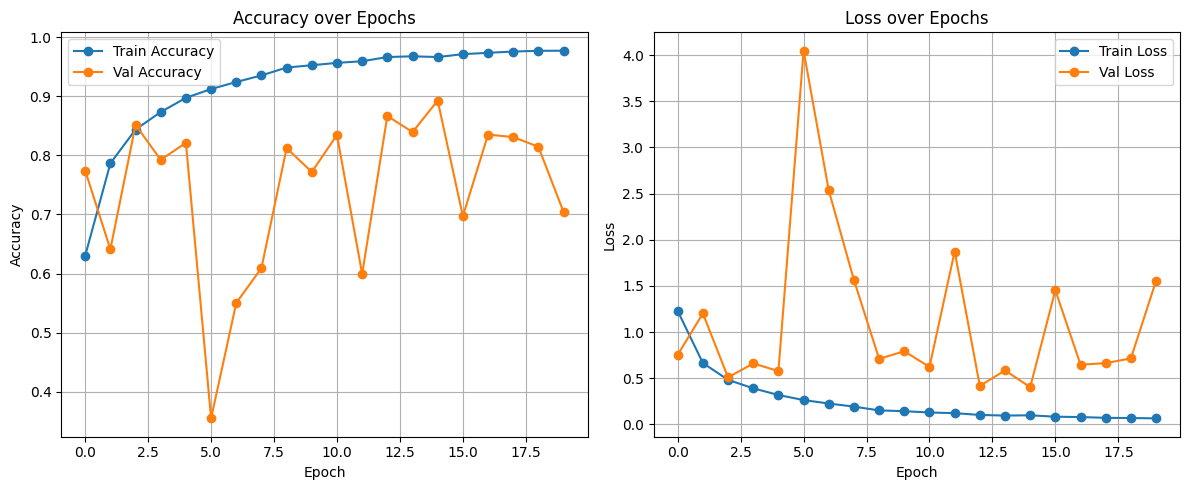

In [23]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [28]:
model.save("plant_disease_model.h5")  # HDF5 format
 

# Take a batch from training data
x_batch = tf.convert_to_tensor(X_train[:32])
y_batch = tf.convert_to_tensor(y_train[:32])

with tf.GradientTape() as tape:
    logits = model(x_batch, training=True)
    loss_value = tf.keras.losses.sparse_categorical_crossentropy(y_batch, logits)

# Get gradients
gradients = tape.gradient(loss_value, model.trainable_variables)

# Save to numpy
for i, grad in enumerate(gradients):
    np.save(f"gradient_layer_{i}.npy", grad.numpy())

 


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


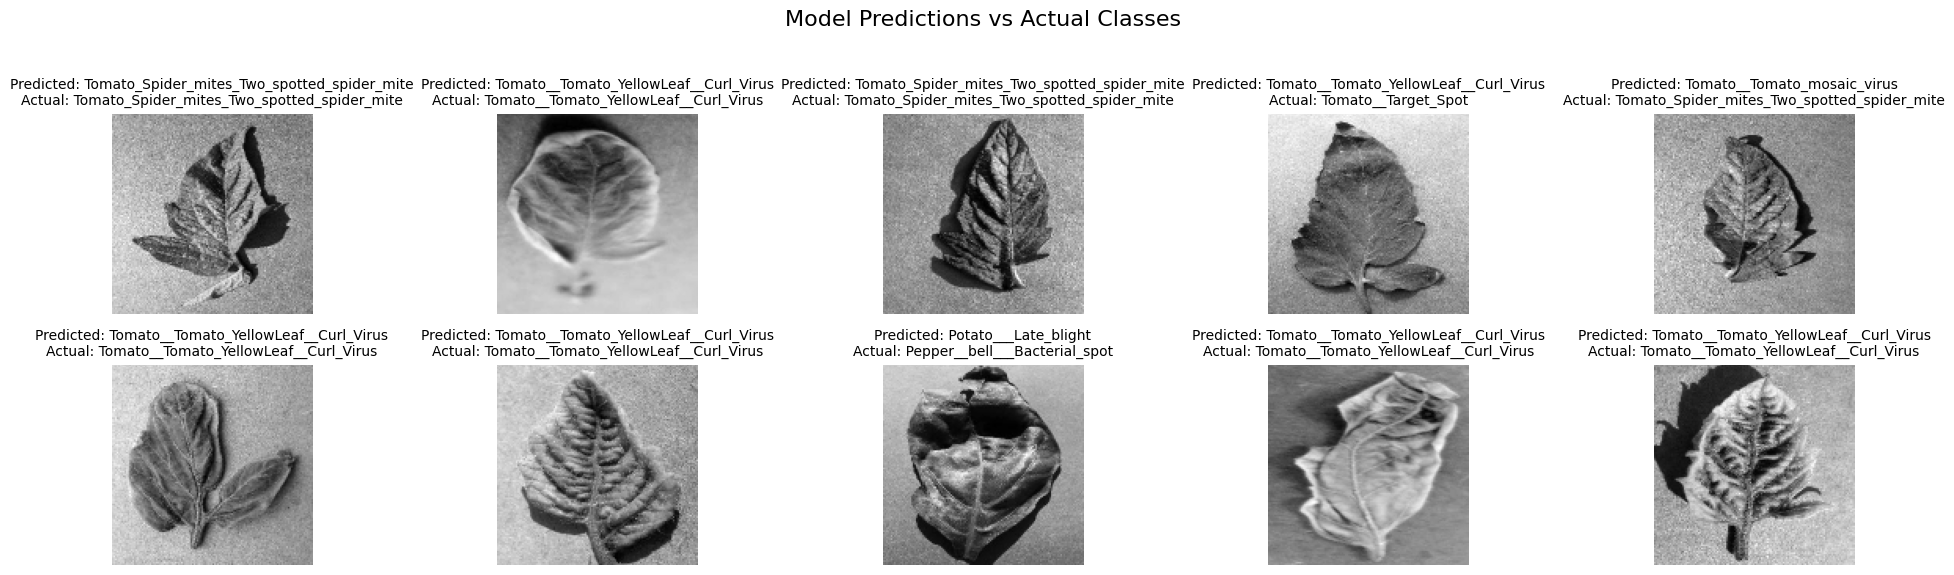

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Select 10 random indices from test set
indices = np.random.choice(len(X_test), size=10, replace=False)
sample_images = X_test[indices]
true_labels = y_test[indices]

# Predict class probabilities and get predicted labels
pred_probs = model.predict(sample_images)
pred_labels = np.argmax(pred_probs, axis=1)

# Decode labels if using LabelEncoder
class_names = label_encoder.classes_
true_class_names = class_names[true_labels]
pred_class_names = class_names[pred_labels]

# Plotting
plt.figure(figsize=(20, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i].squeeze(), cmap='gray')
    plt.title(f"Predicted: {pred_class_names[i]}\nActual: {true_class_names[i]}", fontsize=10)
    plt.axis('off')

plt.suptitle("Model Predictions vs Actual Classes", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step


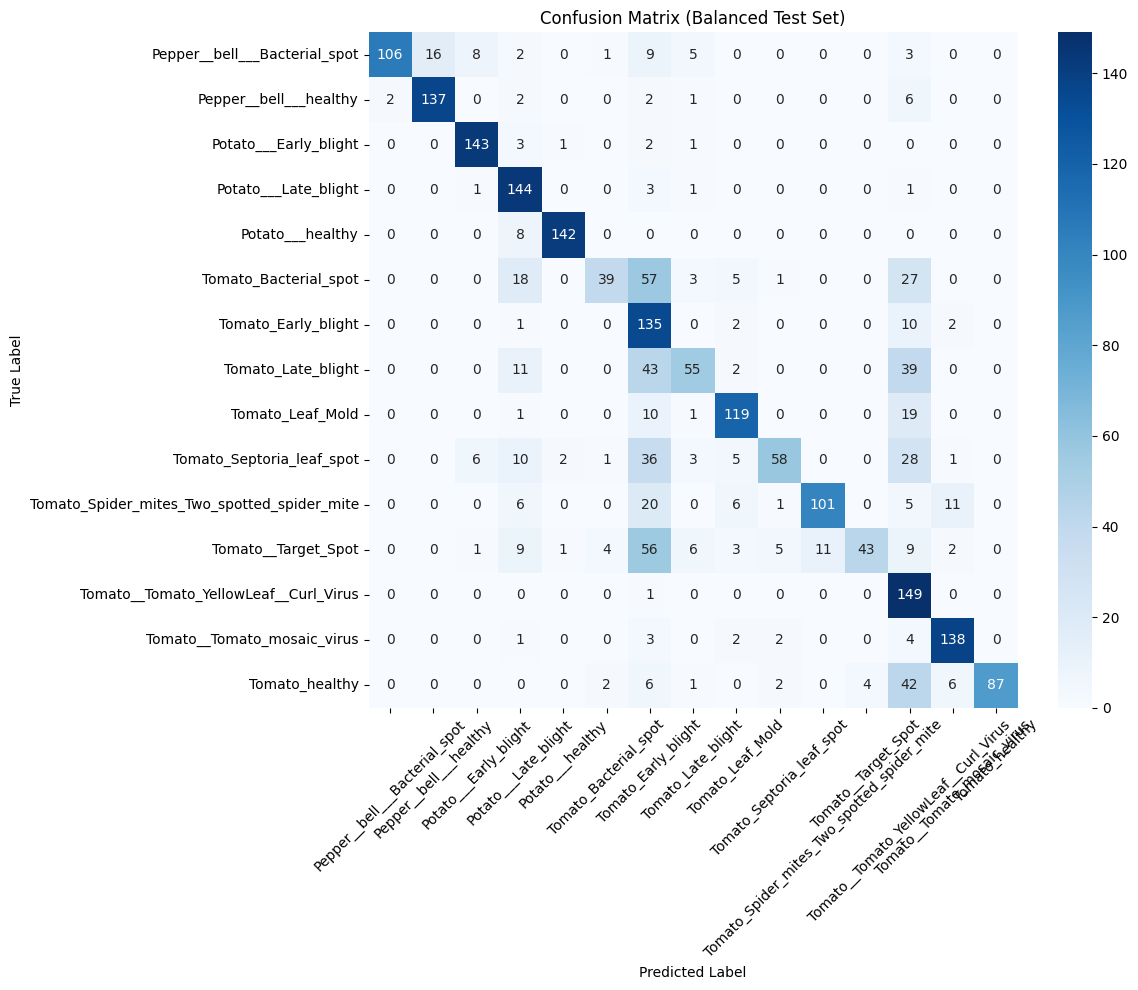

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from collections import defaultdict

# Group images by class
class_indices = defaultdict(list)
for idx, label in enumerate(y_test):
    class_indices[label].append(idx)

# Find minimum samples per class
min_samples = min(len(indices) for indices in class_indices.values())

# Balanced sampling
balanced_indices = []
for indices in class_indices.values():
    balanced_indices.extend(np.random.choice(indices, min_samples, replace=False))

# Prepare balanced test set
X_balanced = X_test[balanced_indices]
y_balanced = y_test[balanced_indices]

# Predict
y_pred_probs = model.predict(X_balanced)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_balanced, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Balanced Test Set)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


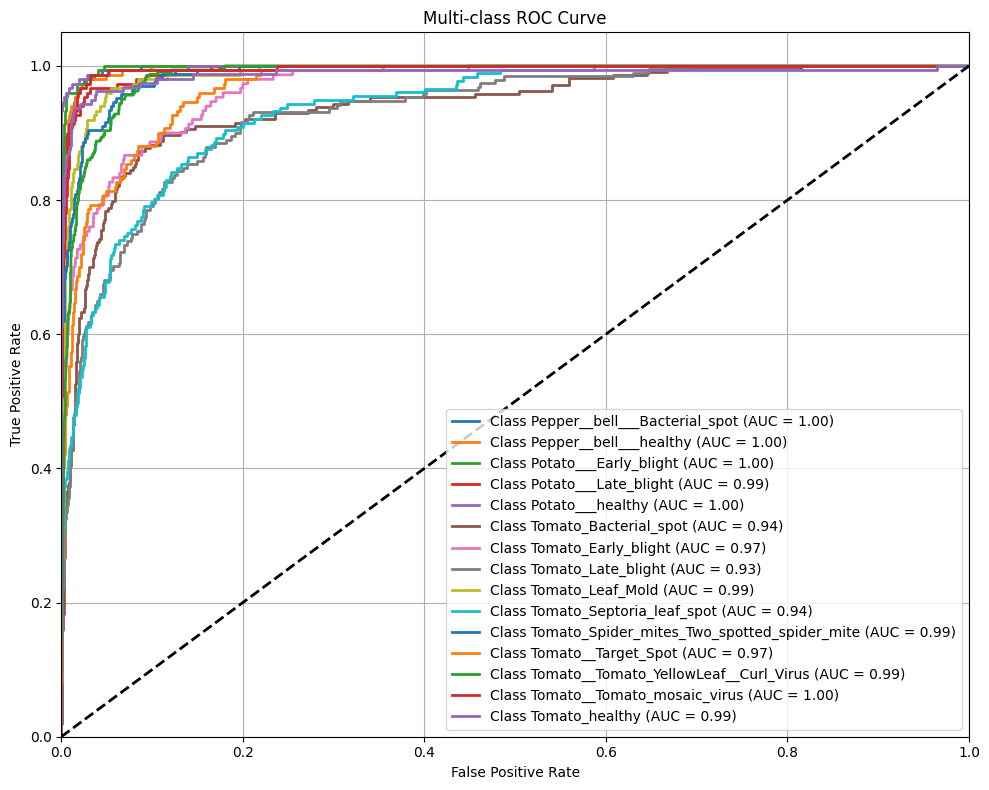

In [34]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Binarize the output
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
y_score = model.predict(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'Class {label_encoder.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()
plt.show()
